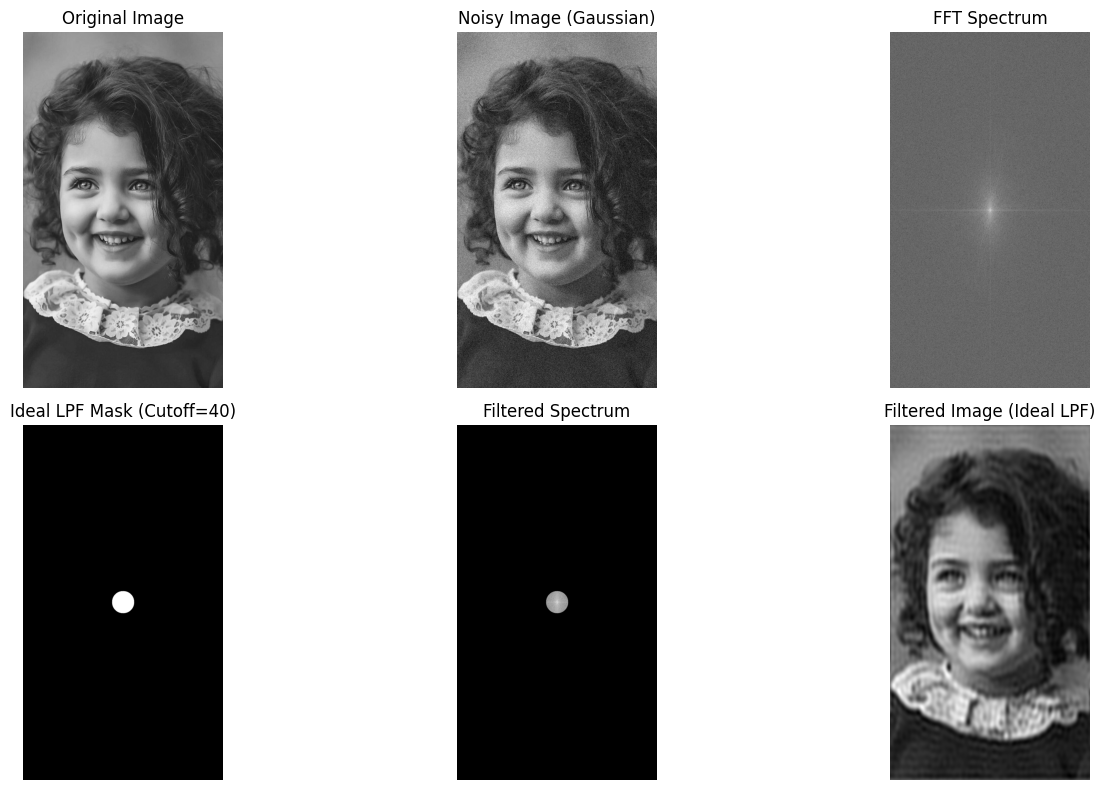

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1️⃣ Read image (grayscale) ---
img = cv2.imread('pk.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("❌ Image not found. Please make sure 'pk.jpg' exists in the same folder.")

# --- 2️⃣ Add Gaussian noise ---
mean, sigma = 0, 20
gaussian_noise = np.random.normal(mean, sigma, img.shape)
noisy_img = np.clip(img.astype(np.float32) + gaussian_noise, 0, 255).astype(np.uint8)

# --- 3️⃣ Apply FFT ---
f = np.fft.fft2(noisy_img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

# --- 4️⃣ Define Ideal Low Pass Filter ---
def ideal_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows)
    v = np.arange(cols)
    V, U = np.meshgrid(v, u)
    D = np.sqrt((U - crow)**2 + (V - ccol)**2)
    H = np.zeros_like(D)
    H[D <= cutoff] = 1  # Ideal pass (sharp cutoff)
    return H

# --- 5️⃣ Create Filter ---
cutoff = 40  # Change this value (e.g. 10, 30, 60) to adjust blur
H_ideal = ideal_lowpass(img.shape, cutoff)

# --- 6️⃣ Apply Filter in Frequency Domain ---
F_ideal = fshift * H_ideal

# --- 7️⃣ Inverse FFT to get filtered image ---
ideal_img = np.abs(np.fft.ifft2(np.fft.ifftshift(F_ideal)))

# --- 8️⃣ Display Results ---
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Noisy Image (Gaussian)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('FFT Spectrum')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(H_ideal, cmap='gray')
plt.title(f'Ideal LPF Mask (Cutoff={cutoff})')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(np.log(1 + np.abs(F_ideal)), cmap='gray')
plt.title('Filtered Spectrum')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(ideal_img, cmap='gray')
plt.title('Filtered Image (Ideal LPF)')
plt.axis('off')

plt.tight_layout()
plt.show()
